# Figure 3: fluctuation spectra and spatial range

**(A)** Eigenvalues of the orbital-pair response $K_{(a,d),(c,b)}=\sum_\mu Q^{\mu\mu}_{adbc}$ (Eq. S5), normalized by their sum.
**(B)** For one bonding unit per material, the fluctuation contributing most to the metric within the unit's block of $K$, its transition kernel rebuilt from the Wannier Hamiltonian and Fourier transformed to lattice displacements; cumulative weight against atom-pair distance, with $r_{90}$ (Eqs. S11–S13).
Panel (C) is a schematic of the $r_{90}$ values printed below.

Inputs, per material in `../data/<material>/`: the orbital-resolved tensors `QM_orb_res_qgt{xx,yy,zz}.npy` (from `Quantum_Metric_Wannier.ipynb`) and `wannier90.win`, `wannier90_hr.dat`, `wannier90_centres.xyz`. `fig3_inputs.json` gives the Fermi level, the bonding-unit seed, the atom positions and the orbital-to-atom map of each computational cell.

Requires numpy, scipy, matplotlib, pythtb 2.0.

In [1]:
import json, itertools
from pathlib import Path
import numpy as np
from scipy.linalg import eigh
from scipy.special import expit
from scipy.sparse import csr_matrix
from pythtb import W90, Lattice, TBModel
import matplotlib.pyplot as plt

O = Path('../data')                              # contains NaCl/, Diamond/, CsI3/, GeTe/
CONFIG = json.loads(Path('fig3_inputs.json').read_text())
MATS = ('NaCl', 'Diamond', 'CsI3', 'GeTe')

## Orbital-pair response and bonding-unit fluctuation

In [2]:
def load_gram(folder, config):
    """Rows (a,d), columns (c,b), from stored Q[a,b,c,d]."""
    G = None
    for name in config['tensor_files']:
        path = folder / name
        Q = np.load(path)
        n = Q.shape[0]
        if Q.shape != (n, n, n, n):
            raise ValueError('Expected four equally sized orbital axes')
        part = Q.transpose(0, 3, 2, 1).reshape(n*n, n*n)
        G = part.copy() if G is None else G + part
    error = np.linalg.norm(G - G.conj().T) / np.linalg.norm(G)
    if error > 1e-10:
        raise ValueError(f'Gram matrix is not Hermitian: {error}')
    return (G + G.conj().T)/2, float(error)


def seed_channels(orbital_to_atom, edges):
    atom = np.asarray(orbital_to_atom)
    mask = np.zeros((len(atom), len(atom)), dtype=bool)
    for a, b in edges:
        mask |= (atom[:, None] == a) & (atom[None, :] == b)
        mask |= (atom[:, None] == b) & (atom[None, :] == a)
    return np.flatnonzero(mask.ravel())


def local_component(G, indices, group_rtol=1e-6):
    """Fixed seed -> local eigenvectors -> lifted components -> metric group.

    The actual producer requires positive local eigenvalues. No eigenvalue
    is clipped, discarded, or replaced. Grouping tolerance is numerical,
    not a claim of exact degeneracy or a symmetry representation.
    """
    H = G[np.ix_(indices, indices)]
    h, V = eigh(H)
    h, V = h[::-1], V[:, ::-1]
    if h[-1] <= 0:
        raise ValueError('Local block is not positive definite; do not clip')
    X = G[:, indices] @ (V / np.sqrt(h))
    q = np.abs(X.sum(axis=0))**2
    groups = []
    start = 0
    while start < len(h):
        end = start + 1
        while end < len(h) and abs(h[end]-h[start]) < group_rtol*h[0]:
            end += 1
        groups.append((start, end))
        start = end
    scores = np.array([q[i:j].sum() for i, j in groups])
    i, j = groups[int(np.argmax(scores))]
    # Columns of E V, for reconstructing the transition rows from the source.
    seeds = np.zeros((len(G), j-i), dtype=complex)
    seeds[indices] = V[:, i:j]
    local_error = np.linalg.norm(X[indices]-V*np.sqrt(h))
    report = dict(selected_ranks_1based=list(range(i+1, j+1)),
                  group_rtol=group_rtol, minimum_local_eigenvalue=float(h[-1]),
                  metric=float(G.sum().real), metric_fraction=float(scores.max()/G.sum().real),
                  local_restriction_error=float(local_error))
    return dict(x=X[:, i:j], seed_vectors=seeds, h_selected=h[i:j],
                local_eigenvalues=h, local_metric_weights=q,
                seed_indices=indices, groups=np.array(groups)), report


def transition_rows(U, J, energies, occupations, seeds, h, nk, nocc):
    """w_j=(E v_j)^dagger B/sqrt(h_j), for ONE k and Cartesian component.

    J is the source Hamiltonian derivative, not a newly chosen velocity.
    Return band-pair matrices, with the producer's finite-T gap weighting.
    """
    n = len(energies)
    gap = energies[None, :] - energies[:, None]
    weight = occupations[:, None]*(1-occupations[None, :])
    weight = np.divide(weight, gap**2, out=np.zeros_like(weight), where=abs(gap) >= .001)
    masks = seeds.T.reshape(-1, n, n)
    W = (U.conj().T[None] @ (masks.conj()*J) @ U[None])
    return W*np.sqrt(weight)[None]/np.sqrt(nk*nocc*h)[:, None, None]

## 2×2×2 supercell (NaCl, diamond, GeTe)

In [3]:
def fold222(p):
 cells=np.array(list(itertools.product(range(2),repeat=3)));n=p.norb
 sc=TBModel(Lattice(2*p.lattice.lat_vecs,(cells[:,None,:]+p.orb_vecs[None]).reshape(-1,3)/2,periodic_dirs=...))
 sc.set_onsite(np.tile(p._site_energies,8));h=p.hoppings
 amp=np.array([z['amplitude'] for z in h]);ii=np.array([z['from_orbital'] for z in h]);jj=np.array([z['to_orbital'] for z in h]);R=np.array([z.get('lattice_vector',[0,0,0]) for z in h])
 target=cells[:,None,:]+R[None];cellidx=(target%2)@np.array([4,2,1])
 src=ii[None]+np.arange(8)[:,None]*n;dst=jj[None]+cellidx*n
 sc._append_hops(np.tile(amp,8),src.ravel(),dst.ravel(),(target//2).reshape(-1,3))
 sc._shift_hop_to_home();sc._lattice._shift_orb_to_home()
 return sc

## Transition kernel in real space

Same amplitudes as the tensors: $|t|\ge10^{-4}$ eV, finite-difference $\partial H/\partial k$ (step $10^{-3}$ Å$^{-1}$), Fermi occupations with $\beta=100$ eV$^{-1}$, shifted $15^3$ mesh. Each Wannier center is placed in the periodic image of its atom before the Fourier transform.

In [4]:
def spatial_kernel(mat, selection):
 config=CONFIG[mat]
 w90=W90(O/mat,'wannier90')
 model=w90.model(min_hopping_norm=.0001)
 if config['fold222']:model=fold222(model)
 n=model.norb;lat=model.lattice.lat_vecs;orb=model.orb_vecs
 h=model.hoppings;ii=np.array([v['from_orbital'] for v in h]);jj=np.array([v['to_orbital'] for v in h]);R=np.array([v.get('lattice_vector',[0,0,0]) for v in h]);t=np.round(np.array([v['amplitude'] for v in h]),10)
 dr=(R+orb[jj]-orb[ii])@lat;onsite=np.round(model._site_energies,10);rec=2*np.pi*np.linalg.inv(lat).T;steps=(np.exp(1j*.001*dr.T)-1)/.001
 scatter=csr_matrix((np.ones(len(ii)),(ii*n+jj,np.arange(len(ii)))),shape=(n*n,len(ii)))
 mu=config['mu_eV']
 values=selection['h_selected']
 seeds=selection['seed_vectors']
 oa=np.array(config['orbital_to_atom']);apos=np.array(config['atom_frac'])@lat
 sym=np.array(config['atom_symbols']);nat=len(sym)
 # Integer rehoming only; keep the producer's non-atomic Wannier-center offsets.
 home=np.rint(orb-apos[oa]@np.linalg.inv(lat)).astype(int);rpos=(orb-home)@lat
 mesh=15;nk=mesh**3;kernels=np.empty((mesh,mesh,mesh,1,3,n,n),complex)
 occ=[]
 for ki,index in enumerate(itertools.product(range(mesh),repeat=3)):
  k=(np.array(index)/mesh-.5)@rec;val=t*np.exp(1j*(dr@k));Hp=(scatter@val).reshape(n,n);H=Hp+Hp.conj().T+np.diag(onsite)
  e,U=np.linalg.eigh(H);count=int(np.sum(e<=mu));occ.append(count);nocc=occ[0]
  f=expit(-100*(e-mu))
  embedding=np.exp(1j*rpos@k);unembed=embedding[:,None]*embedding[None,:].conj()
  for muidx in range(3):
   Jp=(scatter@(val*steps[muidx])).reshape(n,n);J=Jp+Jp.conj().T
   W=transition_rows(U,J,e,f,seeds,values,nk,nocc)
   T=U[None]@W@U.conj().T[None]
   kernels[index+(slice(None),muidx)]=T*unembed
 shifts=np.rint(np.fft.fftfreq(mesh)*mesh).astype(int);RR=np.array(list(itertools.product(shifts,repeat=3)))
 real=np.fft.fftn(kernels[:,:,:,0],axes=(0,1,2),norm='ortho');w=np.sum(abs(real)**2,axis=3).reshape(nk,n,n);del real
 # The shifted grid contributes only a unit-modulus phase per R to coefficients.
 aw=np.zeros((nk,nat,nat))
 for aa in range(n):
  for bb in range(n):aw[:,oa[aa],oa[bb]]+=w[:,aa,bb]
 p=aw.transpose(1,2,0).ravel();keys=np.array([(aa,bb,*rr) for aa in range(nat) for bb in range(nat) for rr in RR],int)
 disp=apos[keys[:,1]]-apos[keys[:,0]]+keys[:,2:]@lat;dist=np.linalg.norm(disp,axis=1);order=np.argsort(dist);cum=np.cumsum(p[order]);r90=float(dist[order[np.searchsorted(cum,.9)]])
 return dict(sorted_distances_A=dist[order],sorted_cumulative_probability=cum,r90_A=r90)

## Run

In [5]:
results = {}
for mat in MATS:
    config = CONFIG[mat]
    G, error = load_gram(O, config)
    indices = seed_channels(config['orbital_to_atom'], config['seed_edges'])
    result, report = local_component(G, indices)
    spectrum = eigh(G, eigvals_only=True)[::-1]
    result['global_eigenvalue_fractions'] = spectrum/spectrum.sum()
    del G
    result.update(spatial_kernel(mat, result))
    results[mat] = result
    print(f"{mat:8s} local rank {report['selected_ranks_1based'][0]}   "
          f"metric fraction {100*report['metric_fraction']:.1f}%   r90 = {result['r90_A']:.2f} A")

NaCl     local rank 1   metric fraction 1.3%   r90 = 4.03 A


Diamond  local rank 1   metric fraction 10.3%   r90 = 3.89 A


CsI3     local rank 2   metric fraction 18.5%   r90 = 5.92 A


GeTe     local rank 4   metric fraction 6.1%   r90 = 12.54 A


## Figure 3 (A, B)

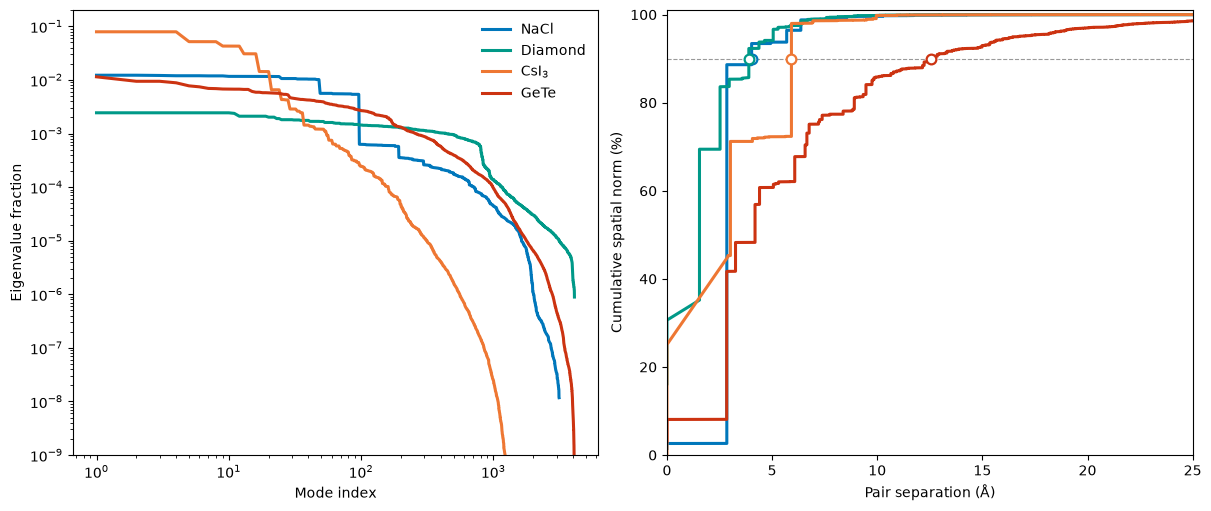

In [6]:
LABEL={'NaCl':'NaCl','Diamond':'Diamond','CsI3':r'CsI$_3$','GeTe':'GeTe'}
COLOR={'NaCl':'#0077bb','Diamond':'#009988','CsI3':'#ee7733','GeTe':'#cc3311'}
tau=.9
plt.rcParams['svg.fonttype']='none'
fig,(sp,di)=plt.subplots(1,2,figsize=(12,5),constrained_layout=True)
for m in MATS:
 z=results[m]
 q=z['global_eigenvalue_fractions']
 sp.loglog(np.arange(1,len(q)+1),q,c=COLOR[m],lw=2.2,label=LABEL[m])
 r80=float(z['sorted_distances_A'][np.searchsorted(z['sorted_cumulative_probability'],tau)])
 di.plot(z['sorted_distances_A'],100*z['sorted_cumulative_probability'],c=COLOR[m],lw=2.2)
 di.plot(r80,100*tau,'o',ms=7,mfc='white',mec=COLOR[m],mew=1.6)
sp.set_xlabel('Mode index');sp.set_ylabel('Eigenvalue fraction');sp.set_ylim(1e-9,.2);sp.legend(frameon=False)
di.set_xlabel('Pair separation (Å)');di.set_ylabel('Cumulative spatial norm (%)');di.set_xlim(0,25);di.set_ylim(0,101);di.axhline(100*tau,c='#999999',ls='--',lw=.8,zorder=0)
fig.savefig('fig3_AB.pdf')
fig.savefig('fig3_AB.svg')
plt.show()